## PharmaNODE — Generic PK → FiLM dataset generator\n
\n
This notebook is for **new users** who want to generate synthetic data from **their own PK model** (not tacrolimus), then train the FiLM model on it.\n
\n
It generates a paired-visit dataset (Visit 1 + Visit 2 per patient) and exports:\n
- `exp_run_all/<exp_name>/virtual_cohort_film_train.csv`\n
- `exp_run_all/<exp_name>/virtual_cohort_film_test.csv`\n
\n
### Recommended CSV format\n
We recommend a simple NONMEM-like event format (minimal columns):\n
- `ID`, `VISIT`, `TIME`, `DV`, `AMT`, `mdv`\n
\n
where:\n
- **Dose/event rows** have `mdv=1`, `AMT=<dose>`, `DV='.'`\n
- **Observation rows** have `mdv=0`, `DV=<observed_value>`, `AMT='.'`\n
\n
You can add extra covariate columns freely.

In [1]:
import os
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchdiffeq import odeint

print('torch:', torch.__version__)
print('device:', 'cuda' if torch.cuda.is_available() else 'cpu')

torch: 2.5.1
device: cpu


### 1) User PK model interface\n
\n
Your model must provide:\n
- an ODE right-hand side (RHS): \\(\\dot{x} = f(t, x, params, covariates)\\)\n
- an observation function: `observe(state, params)` → the scalar you want to model (e.g., concentration)\n
- parameter sampling: `sample_params(rng, covariates)`\n
\n
Below are two examples you can adapt.

In [2]:
class OneCompOralPK(nn.Module):
    """1-compartment oral absorption model.

    State: [A_gut, A_central]
    Observation: C = A_central / V
    Params: ka, CL, V
    """

    def sample_params(self, rng: np.random.Generator, covariates: dict):
        # Typical values (edit for your compound)
        ka = 1.2
        CL = 10.0
        V = 50.0

        # Log-normal IPV (edit SDs)
        ka *= np.exp(rng.normal(0.0, 0.2))
        CL *= np.exp(rng.normal(0.0, 0.3))
        V *= np.exp(rng.normal(0.0, 0.2))
        return {'ka': ka, 'CL': CL, 'V': V}

    def initial_state(self, params: dict) -> torch.Tensor:
        return torch.tensor([0.0, 0.0], dtype=torch.float32)

    def dose_to_state(self, state: torch.Tensor, dose: float) -> torch.Tensor:
        state = state.clone()
        state[0] = state[0] + dose
        return state

    def rhs(self, t: torch.Tensor, state: torch.Tensor, params: dict, covariates: dict):
        A_gut, A_cent = state
        ka = params['ka']
        CL = params['CL']
        V = params['V']
        k = CL / V
        dA_gut = -ka * A_gut
        dA_cent = ka * A_gut - k * A_cent
        return torch.stack([dA_gut, dA_cent])

    def observe(self, state: torch.Tensor, params: dict) -> torch.Tensor:
        return state[1] / float(params['V'])


class TwoCompIVPK(nn.Module):
    """2-compartment IV bolus model.

    State: [A_central, A_periph]
    Params: CL, Vc, Q, Vp
    Observation: C = A_central / Vc
    """

    def sample_params(self, rng: np.random.Generator, covariates: dict):
        CL, Vc, Q, Vp = 12.0, 30.0, 8.0, 80.0
        CL *= np.exp(rng.normal(0.0, 0.25))
        Vc *= np.exp(rng.normal(0.0, 0.2))
        Q *= np.exp(rng.normal(0.0, 0.25))
        Vp *= np.exp(rng.normal(0.0, 0.2))
        return {'CL': CL, 'Vc': Vc, 'Q': Q, 'Vp': Vp}

    def initial_state(self, params: dict) -> torch.Tensor:
        return torch.tensor([0.0, 0.0], dtype=torch.float32)

    def dose_to_state(self, state: torch.Tensor, dose: float) -> torch.Tensor:
        state = state.clone()
        state[0] = state[0] + dose
        return state

    def rhs(self, t: torch.Tensor, state: torch.Tensor, params: dict, covariates: dict):
        A_c, A_p = state
        CL, Vc, Q, Vp = params['CL'], params['Vc'], params['Q'], params['Vp']
        k10 = CL / Vc
        k12 = Q / Vc
        k21 = Q / Vp
        dA_c = -(k10 + k12) * A_c + k21 * A_p
        dA_p = k12 * A_c - k21 * A_p
        return torch.stack([dA_c, dA_p])

    def observe(self, state: torch.Tensor, params: dict) -> torch.Tensor:
        return state[0] / float(params['Vc'])

### 2) Generation configuration\n
\n
Key choices:\n
- `encoder_times_h`: sparse samples shown to the encoder (default is 3 times, to match current FiLM code)\n
- `observation_times_h`: dense target curve times\n
- `ode_rtol/ode_atol`: solver tolerances\n
- noise model parameters

In [3]:
@dataclass
class GenCfg:
    exp_name: str = 'exp_film_generic'
    seed: int = 15

    # cohort
    num_patients: int = 200
    test_fraction: float = 0.2
    n_visits: int = 2

    # sparse encoder sample times (must be 3 for current model)
    encoder_times_h: tuple[float, float, float] = (0.0, 1.0, 3.0)

    # dense target schedule
    observation_times_h: tuple[float, ...] = (0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 9.0, 12.0, 24.0)

    # regimen
    ii_h: float = 24.0
    wash_in_doses: int = 6  # number of doses before the "last" dose at t=0
    dose_candidates: tuple[float, ...] = (1.0, 2.0, 3.0, 4.0)

    # solver
    ode_rtol: float = 1e-6
    ode_atol: float = 1e-6

    # observation noise: y = true + (add + prop*true)*N(0,1)
    noise_add_sd: float = 0.0
    noise_prop_sd: float = 0.05

cfg = GenCfg()

rng = np.random.default_rng(cfg.seed)
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)

out_dir = os.path.join('exp_run_all', cfg.exp_name)
os.makedirs(out_dir, exist_ok=True)
print('out_dir:', out_dir)
print(cfg)

out_dir: exp_run_all/exp_film_generic
GenCfg(exp_name='exp_film_generic', seed=15, num_patients=200, test_fraction=0.2, n_visits=2, encoder_times_h=(0.0, 1.0, 3.0), observation_times_h=(0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 9.0, 12.0, 24.0), ii_h=24.0, wash_in_doses=6, dose_candidates=(1.0, 2.0, 3.0, 4.0), ode_rtol=1e-06, ode_atol=1e-06, noise_add_sd=0.0, noise_prop_sd=0.05)


### 3) Choose your PK model\n
\n
Pick one of the example models, or replace it with your own.

In [4]:
# pk_model = OneCompOralPK()
pk_model = TwoCompIVPK()

pk_model

TwoCompIVPK()

### 4) Simulator helpers\n
\n
We simulate doses during a wash-in period, apply the final dose at t=0, and then output observations on `observation_times_h`.

In [5]:
def simulate_visit(
    pk_model: nn.Module,
    params: dict,
    covariates: dict,
    dose: float,
    ii_h: float,
    wash_in_doses: int,
    observation_times_h: list[float],
    ode_rtol: float,
    ode_atol: float,
):
    # Build dosing times: negative wash-in doses then final dose at t=0
    dosing_times = [-(wash_in_doses - i) * ii_h for i in range(wash_in_doses)] + [0.0]
    dosing_times = sorted(dosing_times)

    # We integrate in segments between dose events, collecting observations.
    obs_times = torch.tensor(observation_times_h, dtype=torch.float32)

    state = pk_model.initial_state(params)
    # apply doses at/ before 0 by stepping through dosing events
    last_t = torch.tensor(dosing_times[0], dtype=torch.float32)
    # start at first dosing time
    if float(last_t.item()) < 0:
        # no state change until first dose event
        pass

    def rhs(t, y):
        return pk_model.rhs(t, y, params, covariates)

    # Apply first dose event
    state = pk_model.dose_to_state(state, dose)

    for event_t in dosing_times[1:]:
        t0 = torch.tensor(float(last_t.item()), dtype=torch.float32)
        t1 = torch.tensor(float(event_t), dtype=torch.float32)
        if t1 > t0:
            # integrate, but we only need the end state
            sol = odeint(rhs, state, torch.stack([t0, t1]), rtol=ode_rtol, atol=ode_atol)
            state = sol[-1]
        # apply dose at this event
        state = pk_model.dose_to_state(state, dose)
        last_t = t1

    # Now integrate from last event (0.0) to observation times
    t0 = torch.tensor(0.0, dtype=torch.float32)
    sol = odeint(rhs, state, torch.cat([t0.view(1), obs_times[obs_times > 0]]), rtol=ode_rtol, atol=ode_atol)

    # sol[0] corresponds to t=0 (post-dose state)
    states_at_obs = torch.vstack([state.view(1, -1), sol[1:]]) if (obs_times > 0).any() else state.view(1, -1)

    true = torch.stack([pk_model.observe(s, params) for s in states_at_obs]).squeeze(-1)
    return obs_times, true


def add_noise(true_y: torch.Tensor, add_sd: float, prop_sd: float) -> torch.Tensor:
    sd = add_sd + prop_sd * true_y.abs()
    y = true_y + sd * torch.randn_like(true_y)
    return torch.clamp(y, min=0.0)


def build_visit_rows(pid: int, visit: int, times: torch.Tensor, obs: torch.Tensor, dose: float) -> list[dict]:
    rows = []
    # dose row at time 0
    rows.append({'ID': pid, 'VISIT': visit, 'TIME': 0.0, 'DV': '.', 'AMT': dose, 'mdv': 1})
    for t, y in zip(times.tolist(), obs.tolist()):
        rows.append({'ID': pid, 'VISIT': visit, 'TIME': float(t), 'DV': float(y), 'AMT': '.', 'mdv': 0})
    return rows

### 5) Generate the full paired-visit cohort

In [6]:
all_rows = []

for pid in range(1, cfg.num_patients + 1):
    covariates = {}  # add user covariates here if needed
    params = pk_model.sample_params(rng, covariates)

    dose_v1 = float(random.choice(cfg.dose_candidates))
    dose_v2 = float(random.choice(cfg.dose_candidates))
    while dose_v2 == dose_v1:
        dose_v2 = float(random.choice(cfg.dose_candidates))

    times1, true1 = simulate_visit(
        pk_model, params, covariates, dose_v1,
        cfg.ii_h, cfg.wash_in_doses, list(cfg.observation_times_h),
        cfg.ode_rtol, cfg.ode_atol,
    )
    obs1 = add_noise(true1, cfg.noise_add_sd, cfg.noise_prop_sd)

    times2, true2 = simulate_visit(
        pk_model, params, covariates, dose_v2,
        cfg.ii_h, cfg.wash_in_doses, list(cfg.observation_times_h),
        cfg.ode_rtol, cfg.ode_atol,
        )
    obs2 = add_noise(true2, cfg.noise_add_sd, cfg.noise_prop_sd)

    all_rows.extend(build_visit_rows(pid, 1, times1, obs1, dose_v1))
    all_rows.extend(build_visit_rows(pid, 2, times2, obs2, dose_v2))

cohort_df = pd.DataFrame(all_rows)
cohort_df.head(10)

,ID,VISIT,TIME,DV,AMT,mdv
0,1,1,0.00,.,2.0,1
1,1,1,0.00,0.08035,.,0
2,1,1,0.25,0.072949,.,0
3,1,1,0.50,0.058393,.,0
4,1,1,1.00,0.046051,.,0
5,1,1,2.00,0.026787,.,0
6,1,1,3.00,0.016588,.,0
7,1,1,4.00,0.011272,.,0
8,1,1,6.00,0.008371,.,0
9,1,1,9.00,0.006942,.,0


### 6) Export train/test CSVs

In [7]:
from sklearn.model_selection import train_test_split

unique_ids = cohort_df['ID'].unique()
train_ids, test_ids = train_test_split(unique_ids, test_size=cfg.test_fraction, shuffle=False)

train_df = cohort_df[cohort_df['ID'].isin(train_ids)].copy()
test_df = cohort_df[cohort_df['ID'].isin(test_ids)].copy()

train_path = os.path.join(out_dir, 'virtual_cohort_film_train.csv')
test_path = os.path.join(out_dir, 'virtual_cohort_film_test.csv')

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print('Wrote:', train_path)
print('Wrote:', test_path)
print('Train patients:', len(train_ids), 'Test patients:', len(test_ids))

Wrote: exp_run_all/exp_film_generic/virtual_cohort_film_train.csv
Wrote: exp_run_all/exp_film_generic/virtual_cohort_film_test.csv
Train patients: 160 Test patients: 40


### 7) Sanity checks + quick plots

Schema OK. Rows: 4800


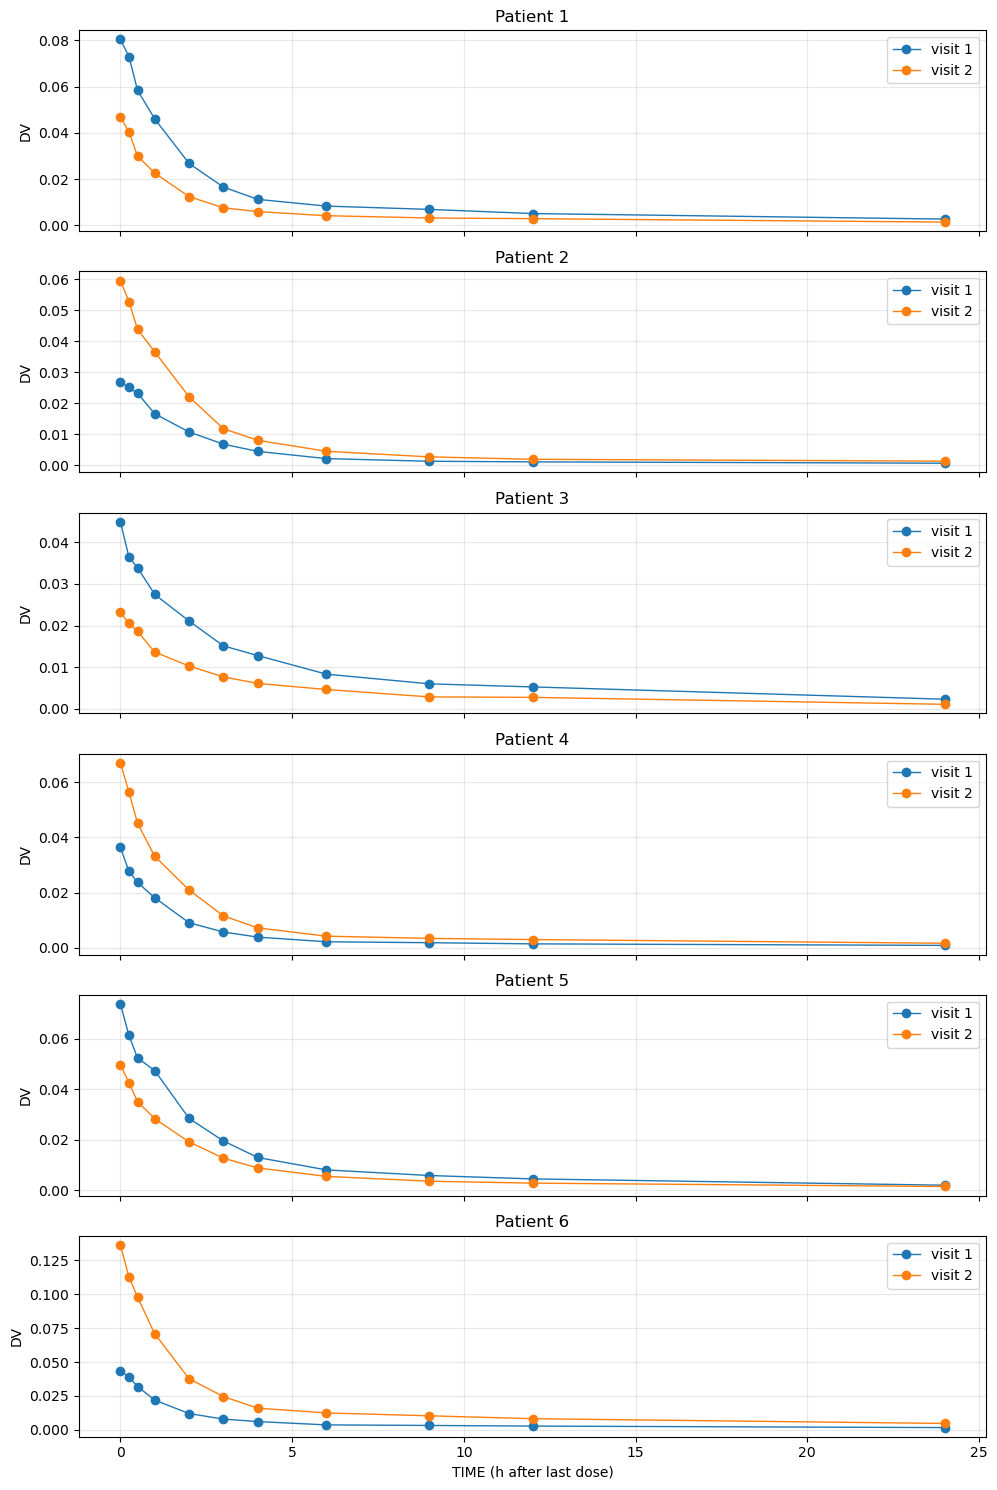

In [8]:
required = {'ID','VISIT','TIME','DV','AMT','mdv'}
missing = sorted(required - set(cohort_df.columns))
assert not missing, f"Missing columns: {missing}"
print('Schema OK. Rows:', len(cohort_df))

def plot_examples(df: pd.DataFrame, n_patients: int = 6):
    ids = list(df['ID'].unique())[:n_patients]
    fig, axes = plt.subplots(len(ids), 1, figsize=(10, 2.5*len(ids)), sharex=True)
    if len(ids) == 1:
        axes = [axes]
    for ax, pid in zip(axes, ids):
        sub = df[(df['ID'] == pid) & (df['mdv'] == 0)].copy()
        sub['DV'] = pd.to_numeric(sub['DV'], errors='coerce')
        for visit in sorted(sub['VISIT'].unique()):
            v = sub[sub['VISIT'] == visit]
            ax.plot(v['TIME'], v['DV'], marker='o', linewidth=1, label=f'visit {visit}')
        ax.set_title(f'Patient {pid}')
        ax.set_ylabel('DV')
        ax.grid(True, alpha=0.3)
        ax.legend()
    axes[-1].set_xlabel('TIME (h after last dose)')
    plt.tight_layout()

plot_examples(cohort_df, n_patients=6)

### Next\n
\n
Run `02_build_reader_and_train_film_generic.ipynb` to map your CSV into the FiLM data contract and train end-to-end.